# ИЗУЧЕНИЕ РЫНКА РОССИЙСКОГО КИНОПРОКАТА

# Шаг 1. Открыть файлы с данными и объединить их в один датафрейм. 

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# загрузим данные
movies_df = pd.read_csv('/datasets/mkrf_movies.csv')
shows_df = pd.read_csv('/datasets/mkrf_shows.csv')

In [3]:
# посмотрим первые 5 строк датасета mkrf_movies (movies)
movies_df.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


In [4]:
# посмотрим количество строк в датасете mkrf_movies (movies)
movies_df.shape[0]

7486

In [5]:
# посмотрим информацию о датасете mkrf_movies (movies)
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

In [6]:
# посмотрим первые 5 строк mkrf_shows (shows)
shows_df.head()

,puNumber,box_office
0,111000113,2.450000e+03
1,111000115,6.104000e+04
2,111000116,1.530300e+08
3,111000117,1.226096e+07
4,111000118,1.636841e+08


In [7]:
# посмотрим количество строк в датасете mkrf_movies (shows)
shows_df.shape[0]

3158

In [8]:
# посмотрим информацию о датасете mkrf_shows (shows)
shows_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB


In [9]:
# замечаем общую колонку "puNumber" в обоих датасетах, обращаем внимание на разные типы данных в этих столбцах
# преобразуем типы данных столбцов к одному общему типу перед выполнением объединения
shows_df['puNumber'] = shows_df['puNumber'].astype(str)

In [10]:
# объединим данные датасетов в датафрейм по столбцу puNumber
merged_df = pd.merge(movies_df, shows_df, on='puNumber', how='outer')

In [11]:
# посмотрим получившийся датафрейм
merged_df.info()
merged_df.describe()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

,refundable_support,nonrefundable_support,budget,box_office
count,3.320000e+02,3.320000e+02,3.320000e+02,3.158000e+03
mean,1.186446e+07,4.898099e+07,1.272297e+08,7.647870e+07
std,2.491656e+07,5.998012e+07,1.885883e+08,2.403531e+08
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,2.500000e+07,4.200000e+07,8.623900e+04
50%,0.000000e+00,3.000000e+07,6.864992e+07,2.327988e+06
75%,1.500000e+07,4.037500e+07,1.419853e+08,2.397967e+07
max,1.800000e+08,4.000000e+08,2.305074e+09,3.073569e+09


In [12]:
# посмотрим первые 5 строк после объединения
merged_df.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


In [13]:
# посмотрим количество строк после объединения
merged_df.shape[0]

7486

Вывод: мы объединили 2 датасета в датафрейм по столбцу 'puNumber', в таблице обнаружили большое количество пропусков, а также некоторые некорректные величины.

# Шаг 2. Предобработка данных

# Шаг 2.1. Проверка типов данных

In [14]:
# посмотрим типы данных
merged_df.dtypes

title                     object
puNumber                  object
show_start_date           object
type                      object
film_studio               object
production_country        object
director                  object
producer                  object
age_restriction           object
refundable_support       float64
nonrefundable_support    float64
budget                   float64
financing_source          object
ratings                   object
genres                    object
box_office               float64
dtype: object

In [15]:
# все-таки "puNumber" это номер прокатного удостоверения, и лучше преобразовать его в числовой тип данных
merged_df['puNumber'] = pd.to_numeric(merged_df['puNumber'], errors='coerce')

In [16]:
# колонка "show_start_date" это дата премьеры фильма, так что лучше привести в типу даты и времени
merged_df['show_start_date'] = pd.to_datetime(merged_df['show_start_date'])

In [17]:
# переведем строковые значения столбца "ratings" в числа
merged_df['ratings'] = pd.to_numeric(merged_df['ratings'], errors='coerce')

In [18]:
# проверим, получилось ли 
merged_df.dtypes

title                                 object
puNumber                             float64
show_start_date          datetime64[ns, UTC]
type                                  object
film_studio                           object
production_country                    object
director                              object
producer                              object
age_restriction                       object
refundable_support                   float64
nonrefundable_support                float64
budget                               float64
financing_source                      object
ratings                              float64
genres                                object
box_office                           float64
dtype: object

Данные преобразованы

# Шаг 2.2. Изучите пропуски в датафрейме

In [19]:
# еще раз посмотрим общую информацию и количество пропусков в датафрейме
merged_df.info()
merged_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7486 non-null   object             
 1   puNumber               7485 non-null   float64            
 2   show_start_date        7486 non-null   datetime64[ns, UTC]
 3   type                   7486 non-null   object             
 4   film_studio            7468 non-null   object             
 5   production_country     7484 non-null   object             
 6   director               7477 non-null   object             
 7   producer               6918 non-null   object             
 8   age_restriction        7486 non-null   object             
 9   refundable_support     332 non-null    float64            
 10  nonrefundable_support  332 non-null    float64            
 11  budget                 332 non-null    float64          

title                       0
puNumber                    1
show_start_date             0
type                        0
film_studio                18
production_country          2
director                    9
producer                  568
age_restriction             0
refundable_support       7154
nonrefundable_support    7154
budget                   7154
financing_source         7154
ratings                   996
genres                    976
box_office               4328
dtype: int64

In [20]:
# заполним пропуски в рейтенгах медианными значениями
median_ratings = merged_df['ratings'].median()
merged_df['ratings'].fillna(median_ratings, inplace=True)

In [21]:
# проверим
merged_df['ratings'].isna().sum()

0

в колонке ретинга пропуски заполнены

остальные пропуски в столбцах "puNumber", "film_studio", "production_country", "director", "producer", "refundable_support", "nonrefundable_support", "budget", "financing_source", "box_office" предлагаю оставить без изменений

In [22]:
# еще предлягаю заменить пропуски в столбце "genres" на "unknown" (т.е. поставить заглушку)
merged_df['genres'] = merged_df['genres'].fillna('unknown')

In [23]:
# проверим
merged_df.isna().sum()

title                       0
puNumber                    1
show_start_date             0
type                        0
film_studio                18
production_country          2
director                    9
producer                  568
age_restriction             0
refundable_support       7154
nonrefundable_support    7154
budget                   7154
financing_source         7154
ratings                     0
genres                      0
box_office               4328
dtype: int64

пропуски в жанрах лучше поменять на "unknown", чтобы в дальнейшем не встречаться с ошибками

Вывод: заполнила медианным значением только пропуске в колонке "ratings", т.к. это дополнит таблице, в остальных же колонках данные могут быть слишком различными, и терть их нельзя, может очень сильно повлиять на исследования, пропуски были заполнены "unknown", т.к. пропуски в некоторых колонках просто напросто не заполнялись в целом, и терять столько информации (удалять их) - нецелесообразно. Ну пока так думаю...
Например данные о бюджетах, средствах гос. поддержки могут просто не разглашаться (коммерческая тайна), некоторые фильмы могут не принадлежать к конкретной студии (независимые проекты, малобюджетные, частные), также отсутствие данных может быть связано с неполнотой информации на момент заполнения, или в концен концов ошибкой в процессе записи уже готовой информаци

# Шаг 2.3. Проверка на дубликаты в датафрейме

In [24]:
# вспомним количество строк в датафрейме
merged_df.shape[0]

7486

In [25]:
# проверим на дупликаты
merged_df.duplicated().sum()
# серьезно? нет? подозрительно...

0

In [26]:
# поищем по другому
duplicates = merged_df.duplicated(subset='title')
merged_df[duplicates]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
3,Особо опасен,221026916.0,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815.0,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
41,Алекс и Эмма,221004616.0,2016-02-09 12:00:00+00:00,Художественный,"Эскейп Артистс, Франчайз Пикчерз, Рейнер-Грэйс...",США,Роб Райнер,"Тодд Блэк, Элан Грейсман, Джереми Левен, Роб Р...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.4,"мелодрама,комедия",NaN
110,Гарри Поттер и орден Феникса /По роману Дж.К.Р...,121026316.0,2016-09-23 12:00:00+00:00,Художественный,"Уорнер Бразерс, Хэйдей Филмз",США - Великобритания,Дэвид Йетс,"Дэйвид Баррон, Дэйвид Хейман",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.7,"фэнтези,приключения,семейный",759526.00
113,Гарри Поттер и узник Азкабана /По роману Дж.К....,121026116.0,2016-09-23 12:00:00+00:00,Художественный,"Хэйдей Филмз, 1492 Пикчерз, Уорнер Бразерс",США,Альфонсо Куарон,Майкл Барната,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.2,"фэнтези,приключения,семейный",1125302.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7369,Невиновен,111019319.0,2019-11-07 12:00:00+00:00,Художественный,"ООО ""Кавказфильм""",Россия,А.Емкужев,"А.Емкужев, А.Хуажева, ООО ""Корпорация Русская ...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.5,"триллер,детектив,криминал",NaN
7416,"Отель ""Гранд Будапешт""",121035119.0,2019-12-13 12:00:00+00:00,Художественный,"Американ Эмпирикал, Индиан Пэинтбраш, Скотт Ру...","Германия, США",Уэс Андерсен,"Уэс Андерсон, Джереми Доусон, Стивен Рейлс",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.9,"комедия,приключения,детектив",NaN
7438,Зверь,121035919.0,2019-12-05 12:00:00+00:00,Художественный,Студио энд Нью,Южная Корея,Ли Джон-хо,"Чан Гён-ик, Чон Джи-хун, Пэк Кён сук",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.5,"триллер,драма",175003.51
7450,В тихом омуте,121036919.0,2019-12-09 12:00:00+00:00,Художественный,"Хэд Гир Филмз, Крео Филмз, Локал Хироу, Метрол...",США,Адам Рэндолл,Мэтт Уолдек,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"триллер,криминал,детектив",NaN


Вот они! зачем нам несколько раз анализировать один и тот же фильмы дважды? предлагаю от них избавиться, но избавиться именно от тех строк, в которых меньше всего информации

In [27]:
merged_df = merged_df.drop_duplicates(subset=['title', 'refundable_support', 'nonrefundable_support', 'budget', 'box_office', 'financing_source'], keep='first')
temp = merged_df[merged_df.duplicated(subset=['title'], keep=False)]
idx = temp[(temp['refundable_support'].isna()) & (temp['nonrefundable_support'].isna()) & (temp['budget'].isna()) & (temp['box_office'].isna()) & (temp['financing_source'].isna())].index
merged_df = merged_df.drop(idx)

In [28]:
# посмотрим теперь
merged_df.shape[0]
#ВУАЛЯ

6802

In [29]:
# посчитаем 
merged_df['title'].value_counts()

Лимб                                                            2
Гарри Поттер и Дары Смерти - Часть 2 /По роману Дж.К.Ролинг/    2
Союз зверей /По книге Эрика Кастнера/                           2
Пингвиненок Пороро: Большие гонки                               2
Снупи и мелочь пузатая в кино                                   2
                                                               ..
Воображариум доктора Парнаса                                    1
МУЛЬТ в кино. Выпуск № 23                                       1
g (джи)                                                         1
Такие разные близнецы                                           1
Курбан-роман. (История с жертвой).                              1
Name: title, Length: 6772, dtype: int64

In [30]:
# удалим
merged_df.drop_duplicates(subset=['title'], inplace=True)

In [31]:
# проверим
merged_df.shape[0]
# ееее

6772

In [32]:
# обновим нумерацию (индексацию)
merged_df.reset_index(drop=True, inplace=True)
merged_df.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915.0,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716.0,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416.0,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Остановился поезд,111013816.0,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,NaN
4,Любовь и голуби,111007013.0,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0


эти пропуски в количественных столбцах могут влиять на исследования, поскольку это количественные значения предлагаю заменить их не средние значения

In [33]:
mean_budget = merged_df['budget'].mean()
merged_df['budget'].fillna(mean_budget, inplace=True)

In [34]:
mean_refundable_support = merged_df['refundable_support'].mean()
merged_df['refundable_support'].fillna(mean_refundable_support, inplace=True)

In [35]:
mean_nonrefundable_support = merged_df['nonrefundable_support'].mean()
merged_df['nonrefundable_support'].fillna(mean_nonrefundable_support, inplace=True)

In [36]:
mean_box_office = merged_df['box_office'].mean()
merged_df['box_office'].fillna(mean_box_office, inplace=True)

In [37]:
# посмотрим
merged_df.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915.0,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,1.186446e+07,4.898099e+07,1.272297e+08,NaN,7.2,"боевик,драма,мелодрама",7.679788e+07
1,Особо важное задание,111013716.0,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,1.186446e+07,4.898099e+07,1.272297e+08,NaN,6.6,"драма,военный",7.679788e+07
2,Особо опасен,221038416.0,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,1.186446e+07,4.898099e+07,1.272297e+08,NaN,6.8,"фантастика,боевик,триллер",7.679788e+07
3,Остановился поезд,111013816.0,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,1.186446e+07,4.898099e+07,1.272297e+08,NaN,7.7,драма,7.679788e+07
4,Любовь и голуби,111007013.0,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,1.186446e+07,4.898099e+07,1.272297e+08,NaN,8.3,"мелодрама,комедия",2.700000e+03


# Шаг 2.4. Проверка категориальных значений

In [38]:
# посмотрим на названия
merged_df['type'].unique()
# может ошибка в пробелах?

array(['Художественный', 'Анимационный', 'Прочие', 'Документальный',
       'Научно-популярный', ' Художественный', ' Анимационный',
       'Музыкально-развлекательный'], dtype=object)

In [39]:
merged_df['type'].value_counts()
# определенно в пробелах...

Художественный                3924
 Художественный               1357
Анимационный                   765
Прочие                         390
Документальный                 282
Научно-популярный               52
 Анимационный                    1
Музыкально-развлекательный       1
Name: type, dtype: int64

In [40]:
# исправим
merged_df['type'] = merged_df['type'].str.strip()

In [41]:
merged_df['type'].value_counts()
# всё - огнище

Художественный                5281
Анимационный                   766
Прочие                         390
Документальный                 282
Научно-популярный               52
Музыкально-развлекательный       1
Name: type, dtype: int64

In [42]:
# посмотрим страны
merged_df['production_country'].unique()

array(['США', 'СССР', 'Франция', 'СССР, Венгрия',
       'Германия-Великобритания', 'Великобритания - Италия',
       'Чехословакия', 'США - Франция - Турция', 'Новая Зеландия',
       'Канада - Франция - Испания', 'США-Германия',
       'США - Великобритания', 'Великобритания', 'США - Германия',
       'Франция - Мексика - США', 'Россия, Казахстан, США',
       'СССР, Швеция', 'СССР, Франция, Англия, Куба, ГДР', 'Германия',
       'Великобритания-США-Германия-КНР',
       'СССР, ЧССР, Западный Берлин, ПНР', 'СССР, Италия', 'Гонконг, КНР',
       'США - Франция', 'США - Япония - Франция - Великобритания',
       'Гонконг - Сингапур - Таиланд - Великобритания', 'США-Канада',
       'Франция - Италия - Великобритания - США', 'Франция - США',
       'Ирландия-Великобритания-Германия', 'Чехия', 'США-Австралия',
       'СССР, Финляндия', 'США-Франция-Великобритания-Австрия',
       'США - Бельгия', 'США - Ирландия - Великобритания',
       'Великобритания - США',
       'Люксембург - Нидерл

In [43]:
# посмотррим студии
merged_df['film_studio'].unique() 

array(['Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикчерз, Тиг Продакшнз',
       'Киностудия "Мосфильм"',
       'Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз',
       ...,
       'Дэниел Гродник Продакшнз, Вандерфилм Медиа Корпорэйшн, Импринт Интертейнмент, Вор Хорс Интертейнмент, Пимиента ',
       'Никелодеон Анимейшн Студиос, Спин Мастер',
       'Анимаккорд Лтд., ООО Студия "АНИМАККОРД"'], dtype=object)

в целом одна и та же ошибка, названия в категориальных колонках заполняются по разныму

Вывод: пробелы в названиях (до, после), пробелы или их отсутствие со знаком "-", а также смена местами слов

# Шаг 2.5. Проверка количественных значений

In [44]:
merged_df.describe() 

,puNumber,refundable_support,nonrefundable_support,budget,ratings,box_office
count,6.771000e+03,6.772000e+03,6.772000e+03,6.772000e+03,6772.000000,6.772000e+03
mean,1.296427e+08,1.186446e+07,4.898099e+07,1.272297e+08,6.473833,7.679788e+07
std,3.264824e+07,5.509036e+06,1.326157e+07,4.169677e+07,1.029019,1.639522e+08
min,1.811096e+06,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.000000e+00
25%,1.120019e+08,1.186446e+07,4.898099e+07,1.272297e+08,6.000000,3.369518e+06
50%,1.210129e+08,1.186446e+07,4.898099e+07,1.272297e+08,6.600000,7.679788e+07
75%,1.210382e+08,1.186446e+07,4.898099e+07,1.272297e+08,7.100000,7.679788e+07
max,2.310010e+08,1.800000e+08,4.000000e+08,2.305074e+09,9.200000,3.073569e+09


In [45]:
# хочу привести такие данные, к удобному для себя восприятию через цикл
for column in ['puNumber', 'refundable_support', 'nonrefundable_support', 'budget', 'box_office']:
    merged_df[column] = merged_df[column] / 1000000

In [46]:
merged_df.describe() 

,puNumber,refundable_support,nonrefundable_support,budget,ratings,box_office
count,6771.000000,6772.000000,6772.000000,6772.000000,6772.000000,6772.000000
mean,129.642705,11.864458,48.980989,127.229717,6.473833,76.797875
std,32.648242,5.509036,13.261569,41.696770,1.029019,163.952226
min,1.811096,0.000000,0.000000,0.000000,1.000000,0.000000
25%,112.001919,11.864458,48.980989,127.229717,6.000000,3.369518
50%,121.012917,11.864458,48.980989,127.229717,6.600000,76.797875
75%,121.038169,11.864458,48.980989,127.229717,7.100000,76.797875
max,231.001012,180.000000,400.000000,2305.074303,9.200000,3073.568691


в столбцах "budget" и "box_office" выявлены необычно высокие значения максимальных и средних значений по сравнению с остальными данными. Такие выбросы могут быть результатом ошибок в данных или наличия крайне успешных фильмов
также "budget" связан с "refundable_support" и "nonrefundable_support" тем, что представляет их сумму в общем бюджете фильма

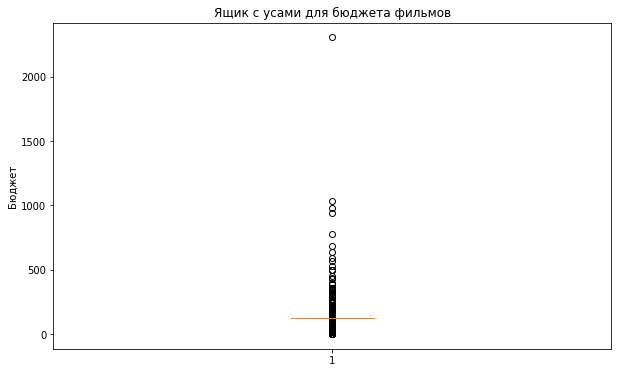

In [47]:
# построим ящик с усами для бюджета
data = merged_df['budget'].tolist()

plt.figure(figsize=(10, 6))  
plt.boxplot(data)
plt.title('Ящик с усами для бюджета фильмов')
plt.ylabel('Бюджет')
plt.show()

думаю не стоит избавляться от выбросов... фильмы же могут быть супер, а могут быть не очень, выбросов много, лучше оставить все как есть.

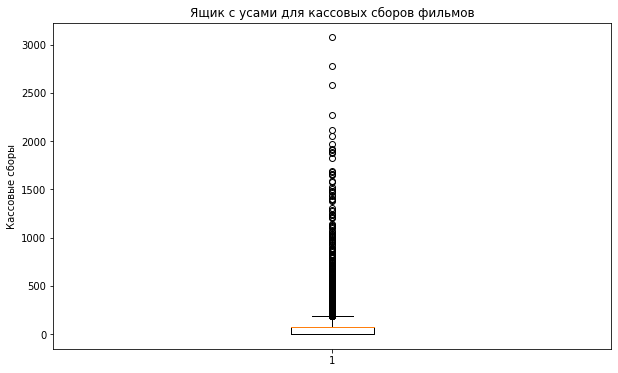

In [48]:
# построим ящик с усами для кассовых сборов
data = merged_df['box_office'].tolist()

plt.figure(figsize=(10, 6))  
plt.boxplot(data)
plt.title('Ящик с усами для кассовых сборов фильмов')
plt.ylabel('Кассовые сборы')
plt.show()

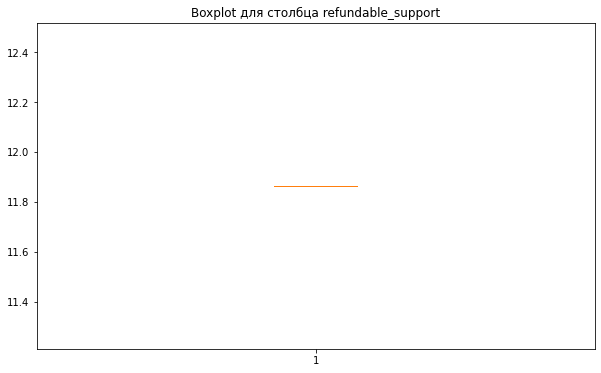

In [49]:
plt.figure(figsize=(10,6))
plt.boxplot(merged_df['refundable_support'].dropna(), sym='')
plt.title('Boxplot для столбца refundable_support')
plt.show()

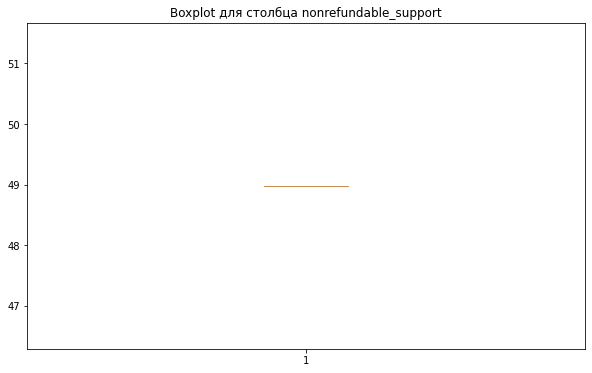

In [50]:
plt.figure(figsize=(10,6))
plt.boxplot(merged_df['nonrefundable_support'].dropna(), sym='')
plt.title('Boxplot для столбца nonrefundable_support')
plt.show()

прямые получилось из-за средних значений в этих столбцах... уже сомневаюсь, что это правильно

In [51]:
# посмотрим корреляцию
merged_df[['budget', 'refundable_support', 'nonrefundable_support']].corr()

,budget,refundable_support,nonrefundable_support
budget,1.000000,0.641224,0.594169
refundable_support,0.641224,1.000000,0.359622
nonrefundable_support,0.594169,0.359622,1.000000


видно, что бюджет имеет сильную положительную корреляцию как с возвратной поддержкой (0.641), так и с невозвратной поддержкой (0.594). Таким образом, можно сделать вывод, что чем больше бюджет, тем вероятнее получение как возвратной, так и невозвратной поддержки. В то же время, возвратная поддержка слабее коррелирует с невозвратной поддержкой (0.36), что может указывать на то, что эти два типа поддержки могут быть предоставлены независимо друг от друга в разных ситуациях.

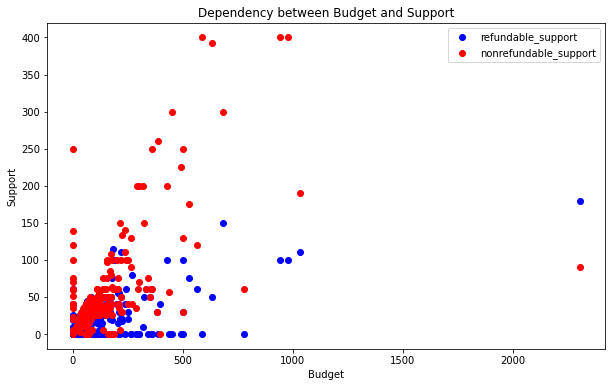

In [52]:
plt.figure(figsize=(10,6))

plt.scatter(merged_df['budget'], merged_df['refundable_support'], label='refundable_support', color='blue')
plt.scatter(merged_df['budget'], merged_df['nonrefundable_support'], label='nonrefundable_support', color='red')

plt.xlabel('Budget')
plt.ylabel('Support')
plt.title('Dependency between Budget and Support')
plt.legend()

plt.show()

# Шаг 2.6. Добавление новых столбцов

- Создание столбца с информацией о годе проката. 

In [53]:
# создадим колонку только с годом релиза
merged_df['rental_year'] = pd.to_datetime(merged_df['show_start_date']).dt.year

In [54]:
merged_df.head() 
# огонь

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,rental_year
0,Открытый простор,221.048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,11.864458,48.980989,127.229717,NaN,7.2,"боевик,драма,мелодрама",76.797875,2015
1,Особо важное задание,111.013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,11.864458,48.980989,127.229717,NaN,6.6,"драма,военный",76.797875,2016
2,Особо опасен,221.038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,11.864458,48.980989,127.229717,NaN,6.8,"фантастика,боевик,триллер",76.797875,2016
3,Остановился поезд,111.013816,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,11.864458,48.980989,127.229717,NaN,7.7,драма,76.797875,2016
4,Любовь и голуби,111.007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,11.864458,48.980989,127.229717,NaN,8.3,"мелодрама,комедия",0.002700,2013


- Создание двух столбцов: с именем и фамилией главного режиссёра и основным жанром фильма. 

In [55]:
# создадим сразу 2 столбца, преобразуем данные и затем столбец с главным режиссером (тот кто первый написан), потом жанр (тож первый)
def get_first_value(text):
    return str(text).split(',')[0] 

merged_df['director_name'] = merged_df['director'].apply(get_first_value)
merged_df['main_genre'] = merged_df['genres'].apply(get_first_value)

In [56]:
merged_df.head() 

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,rental_year,director_name,main_genre
0,Открытый простор,221.048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,11.864458,48.980989,127.229717,NaN,7.2,"боевик,драма,мелодрама",76.797875,2015,Кевин Костнер,боевик
1,Особо важное задание,111.013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,11.864458,48.980989,127.229717,NaN,6.6,"драма,военный",76.797875,2016,Е.Матвеев,драма
2,Особо опасен,221.038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,11.864458,48.980989,127.229717,NaN,6.8,"фантастика,боевик,триллер",76.797875,2016,Тимур Бекмамбетов,фантастика
3,Остановился поезд,111.013816,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,11.864458,48.980989,127.229717,NaN,7.7,драма,76.797875,2016,В.Абдрашитов,драма
4,Любовь и голуби,111.007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,11.864458,48.980989,127.229717,NaN,8.3,"мелодрама,комедия",0.002700,2013,В.Меньшов,мелодрама


- Подсчет доли, которя составляет государственная поддержка от общего бюджета фильма.

In [57]:
# создадим столбец с долями 
merged_df['government_support_share'] = (merged_df['refundable_support'] + merged_df['nonrefundable_support']) / merged_df['budget'] * 100

In [58]:
merged_df.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,rental_year,director_name,main_genre,government_support_share
0,Открытый простор,221.048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,11.864458,48.980989,127.229717,NaN,7.2,"боевик,драма,мелодрама",76.797875,2015,Кевин Костнер,боевик,47.823298
1,Особо важное задание,111.013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,11.864458,48.980989,127.229717,NaN,6.6,"драма,военный",76.797875,2016,Е.Матвеев,драма,47.823298
2,Особо опасен,221.038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,11.864458,48.980989,127.229717,NaN,6.8,"фантастика,боевик,триллер",76.797875,2016,Тимур Бекмамбетов,фантастика,47.823298
3,Остановился поезд,111.013816,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,11.864458,48.980989,127.229717,NaN,7.7,драма,76.797875,2016,В.Абдрашитов,драма,47.823298
4,Любовь и голуби,111.007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,11.864458,48.980989,127.229717,NaN,8.3,"мелодрама,комедия",0.002700,2013,В.Меньшов,мелодрама,47.823298


успех

После добавления столбца с долями гос. поддержки от бюджета, можно сделать вывод, что гос. поддержка зависит от определенных факторов, и после добавления данного столбца теперь можно сделать более детальный анализ, например оценить влияние гос. поддержки на кассовые сборы, в общем сделать детальный анализ

# Шаг 3. Исследовательский анализ данных


- Сколько фильмов выходило в прокат каждый год? Подсчет доли, которую составляют фильмы с указанной информацией о прокате в кинотеатрах. Анализ изменения этой доли по годам. Какой период представлен в данных полнее всего?

In [59]:
# посмотрим количества фильмов для каждого из годов релиза
movies_per_year = merged_df['rental_year'].value_counts().sort_index()
movies_per_year

2010    764
2011    481
2012    525
2013    590
2014    735
2015    666
2016    741
2017    497
2018    876
2019    897
Name: rental_year, dtype: int64

в 2010 больше вего релизов

In [60]:
# посчитаем количества фильмов с информацией о прокате
films_with_rental_info = merged_df[merged_df['rental_year'].notnull()]
num_films_with_rental_info = films_with_rental_info.shape[0]

In [61]:
# сколько всего фильмов
total_films = merged_df.shape[0]

In [62]:
# вычислим доли
rental_info_share = (num_films_with_rental_info / total_films) * 100

In [63]:
f"Доля фильмов с информацией о прокате: {rental_info_share:.2f}%"

'Доля фильмов с информацией о прокате: 100.00%'

In [64]:
# посмотрим информацию о доле фильмов в прокате от общего количества , естественно по годам
rental_info_by_year = films_with_rental_info.groupby('rental_year').size()

total_films_by_year = merged_df.groupby('rental_year').size()

rental_info_share_by_year = pd.DataFrame({'rental_info': rental_info_by_year, 'total_films': total_films_by_year})
rental_info_share_by_year['rental_share'] = (rental_info_share_by_year['rental_info'] / rental_info_share_by_year['total_films']) * 100

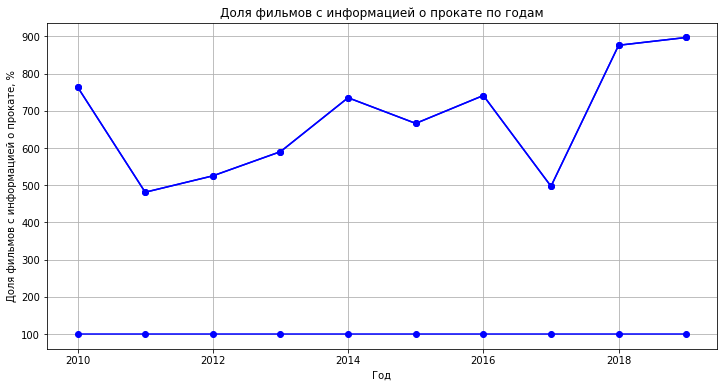

In [65]:
# построим график
plt.figure(figsize=(12, 6))
plt.plot(rental_info_share_by_year.index, rental_info_share_by_year, marker='o', color='b', linestyle='-')

plt.xlabel('Год')
plt.ylabel('Доля фильмов с информацией о прокате, %')
plt.title('Доля фильмов с информацией о прокате по годам')

plt.grid(True)
plt.show()

больше информации представляется начиная с 2018 года

- Изучение изменения динамики проката по годам. В каком году сумма сборов была минимальной? А максимальной?

In [66]:
yearly_box_office = merged_df.groupby('rental_year')['box_office'].sum()

In [67]:
min_year = yearly_box_office.idxmin()
(f"Год с минимальной суммой сборов: {min_year}")

'Год с минимальной суммой сборов: 2011'

In [68]:
max_year = yearly_box_office.idxmax()
(f"Год с максимальной суммой сборов: {max_year}")

'Год с максимальной суммой сборов: 2018'

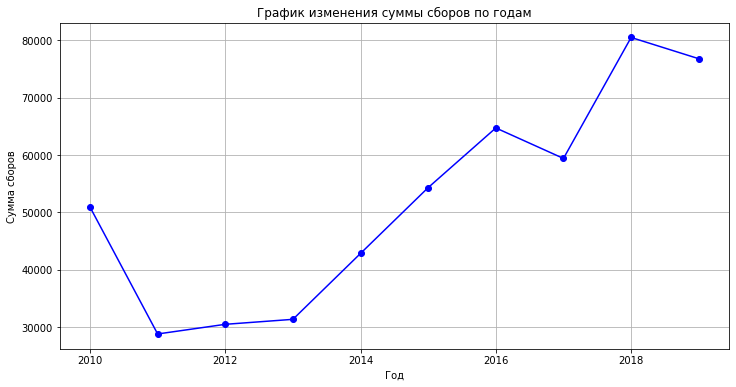

In [69]:
early_box_office = merged_df.groupby('rental_year')['box_office'].sum()

plt.figure(figsize=(12, 6))
plt.plot(yearly_box_office.index, yearly_box_office.values, marker='o', color='b', linestyle='-')
plt.title('График изменения суммы сборов по годам')
plt.xlabel('Год')
plt.ylabel('Сумма сборов')
plt.grid(True)
plt.show()

Год с минимальной суммой сборов: 2011
Год с максимальной суммой сборов: 2018

- Подсчет средней и медианной сумм сборов для каждого года с помощью сводной таблицы.

In [70]:
# создадим сводную таблицу с суммой сборов для каждого года
yearly_box_office = merged_df.groupby('rental_year')['box_office'].sum()

# и теперь со средней и медианной суммой сборов для каждого года
summary_table = merged_df.groupby('rental_year')['box_office'].agg(['mean', 'median'])
summary_table

,mean,median
rental_year,,
2010,66.648452,76.797875
2011,59.902795,76.797875
2012,58.087070,76.797875
2013,53.158152,76.797875
2014,58.297456,76.797875
2015,81.552567,36.268335
2016,87.318483,29.822147
2017,119.497092,41.066347
2018,91.854282,76.797875


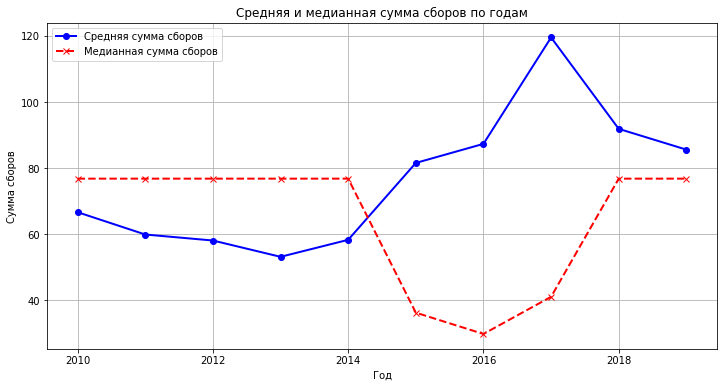

In [71]:
# посмотрим на графике
plt.figure(figsize=(12, 6))
plt.plot(summary_table.index, summary_table['mean'], label='Средняя сумма сборов', marker='o', color='b', linestyle='-', linewidth=2)
plt.plot(summary_table.index, summary_table['median'], label='Медианная сумма сборов', marker='x', color='r', linestyle='--', linewidth=2)

plt.title('Средняя и медианная сумма сборов по годам')
plt.xlabel('Год')
plt.ylabel('Сумма сборов')
plt.legend()
plt.grid(True)
plt.show()

- Влияет ли возрастное ограничение аудитории («6+», «12+», «16+», «18+» и т. д.) на сборы фильма в прокате в период с 2015 по 2019 год? Фильмы с каким возрастным ограничением собрали больше всего денег в прокате? Меняется ли картина в зависимости от года?

In [72]:
# сгроуппируем по возрастному ограничению и году проката, суммирование сборов
age_restriction_revenue = merged_df.groupby(['age_restriction', 'rental_year'])['box_office'].sum()

In [73]:
# какие ограничения больше собрали?
top_age_rating = age_restriction_revenue.groupby('age_restriction').sum().idxmax()
(f"Фильмы с возрастным ограничением '{top_age_rating}' собрали больше всего денег в прокате.")

"Фильмы с возрастным ограничением '«16+» - для детей старше 16 лет' собрали больше всего денег в прокате."

In [74]:
# посмотрим изменения по годам
revenue_by_year = age_restriction_revenue.unstack()
revenue_by_year

rental_year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
age_restriction,,,,,,,,,,
«0+» - для любой зрительской аудитории,7220.887123,4851.713536,4149.351746,3458.614688,3140.283007,1041.346520,2146.928305,3378.311815,5561.896019,5393.597333
«12+» - для детей старше 12 лет,11059.014180,3379.326401,4147.193997,8007.889361,16024.410130,18377.550273,15865.760366,9924.970292,27169.334700,21127.501187
«16+» - для детей старше 16 лет,28261.982758,17126.298690,16591.595267,12057.921661,11756.768611,16143.306495,21085.020110,21046.826206,22263.442990,18897.249003
«18+» - запрещено для детей,4377.533273,3455.905426,5452.831722,5764.981628,7739.159764,8286.178286,11939.387460,11417.846711,11832.000511,15036.685315
«6+» - для детей старше 6 лет,NaN,0.000450,154.739160,2073.902383,4188.008766,10465.628102,13665.899788,13622.099650,13637.676884,16308.453036


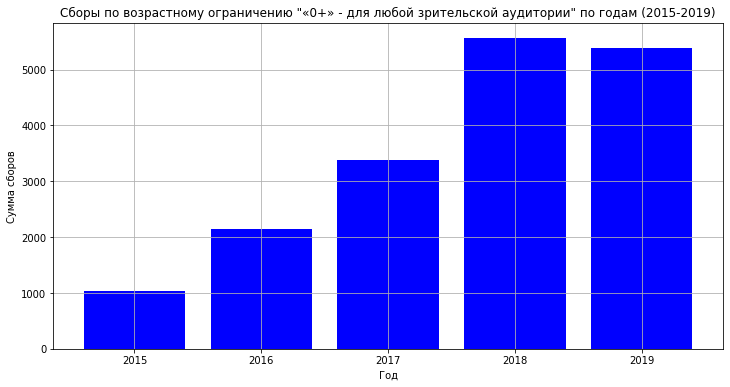

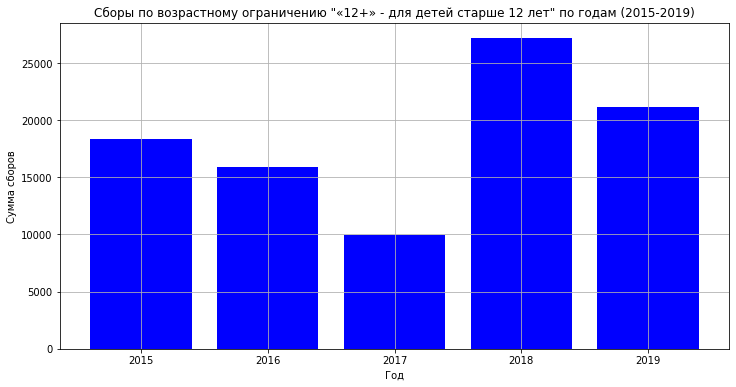

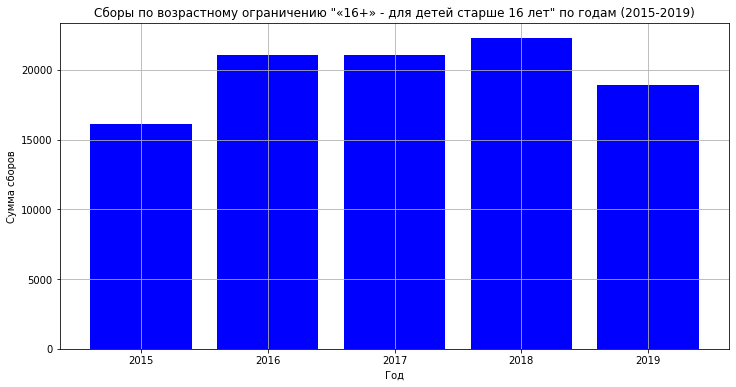

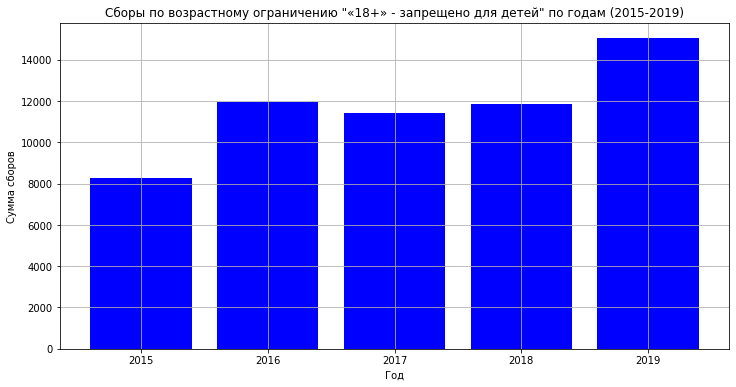

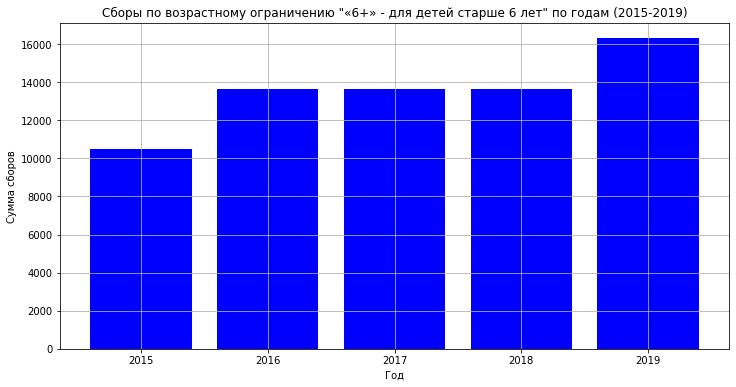

In [75]:
age_restriction_revenue_filtered = age_restriction_revenue.loc[age_restriction_revenue.index.get_level_values('rental_year').isin([2015, 2016, 2017, 2018, 2019])]

# построим графики для каждого возрастного ограничения с 2015 по 2019 года
for age_restriction in age_restriction_revenue_filtered.index.get_level_values('age_restriction').unique():
    data = age_restriction_revenue_filtered.loc[age_restriction]
    plt.figure(figsize=(12, 6))
    plt.bar(data.index, data.values, color='b')
    plt.title(f'Сборы по возрастному ограничению "{age_restriction}" по годам (2015-2019)')
    plt.xlabel('Год')
    plt.ylabel('Сумма сборов')
    plt.grid(True)
    plt.show()

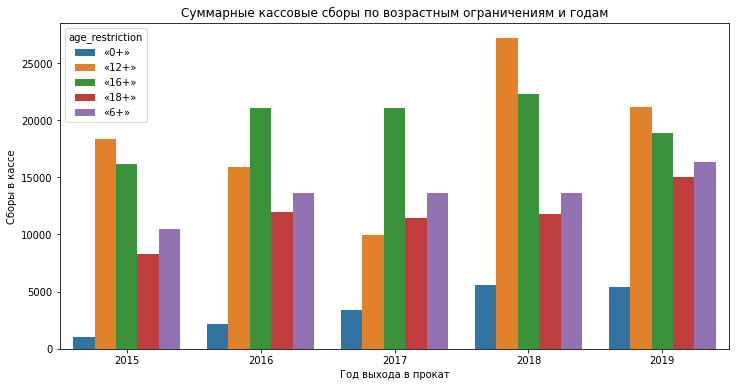

In [76]:
# посмотрим по-другому
year_age = (
    merged_df.query('rental_year in [2015, 2016, 2017, 2018, 2019]')
        .pivot_table(index = ['age_restriction', 'rental_year'], values = 'box_office', aggfunc = 'sum').reset_index()
)

plt.figure(figsize=(12, 6))
fig = sns.barplot(data=year_age, x='rental_year', y='box_office', hue='age_restriction')
for label in fig.legend_.texts:
    label.set_text(label.get_text().split(" ", maxsplit=1)[0])

plt.title('Суммарные кассовые сборы по возрастным ограничениям и годам')
plt.xlabel('Год выхода в прокат') 
plt.ylabel('Сборы в кассе') 
plt.show()

Фильмы с возрастным ограничением '«16+» - для детей старше 16 лет' собрали больше всего денег в прокате. 

# Шаг 4. Исследование фильмов, которые получили государственную поддержку

In [77]:
total_support = merged_df.groupby('production_country')[['refundable_support', 'nonrefundable_support']].sum()
total_support

,refundable_support,nonrefundable_support
production_country,,
СССР,23.728916,97.961978
СССР,11.864458,48.980989
СССР,11.864458,48.980989
2019,11.864458,48.980989
CША,11.864458,48.980989
...,...,...
"Япония, Великобритания",11.864458,48.980989
"Япония, Великобритания, Австрия, Германия, Ю.Корея",11.864458,48.980989
"Япония, США",11.864458,48.980989


In [78]:
total_support.describe()

,refundable_support,nonrefundable_support
count,942.000000,942.000000
mean,85.267919,352.018360
std,997.315044,4121.203709
min,0.000000,20.000000
25%,11.864458,48.980989
50%,11.864458,48.980989
75%,11.864458,48.980989
max,21303.397590,88123.539573


In [79]:
# по жанру фильма вычислим средние кассовые сборы и рейтинги
avg_box_office = merged_df.groupby('main_genre')['box_office'].mean().sort_values(ascending=False)
avg_ratings = merged_df.groupby('main_genre')['ratings'].mean().sort_values(ascending=False)

# посмотрим 
print("Средние кассовые сборы по жанрам:")
print(avg_box_office)
print("\n")
print("Средний рейтинг по жанрам:")
print(avg_ratings)

Средние кассовые сборы по жанрам:
main_genre
спорт              372.509149
фантастика         181.122443
история            138.610867
фэнтези            133.127942
мультфильм         101.777738
боевик              95.171158
детектив            92.972574
мюзикл              87.201106
биография           85.840481
вестерн             79.336654
военный             76.125685
семейный            72.783070
короткометражка     70.896009
комедия             70.706184
приключения         69.713245
ужасы               68.570292
unknown             66.306872
концерт             62.882607
аниме               59.799001
триллер             57.881618
мелодрама           56.730111
драма               54.824826
криминал            53.265974
музыка              51.023727
документальный      41.421709
для взрослых        38.786043
реальное ТВ         32.721103
детский             22.097202
фильм-нуар           0.001700
Name: box_office, dtype: float64


Средний рейтинг по жанрам:
main_genre
фильм-нуар  

In [80]:
merged_df = merged_df[merged_df['box_office'] != 0]

# сделаем сортировку по кассовым сборам
sorted_df = merged_df.sort_values(by='box_office')

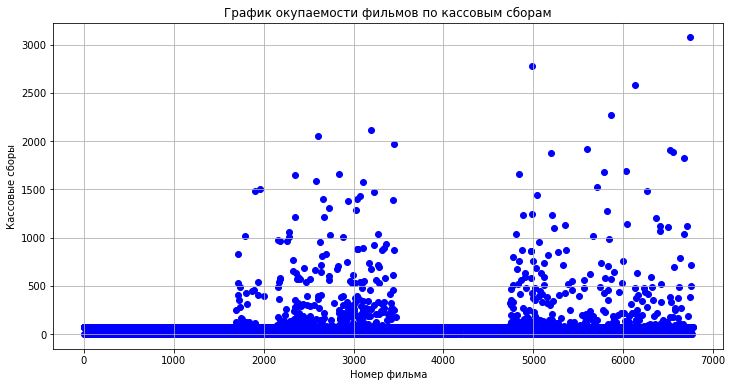

In [81]:
# построим график
plt.figure(figsize=(12, 6))
plt.scatter(sorted_df.index, sorted_df['box_office'], color='b')
plt.title('График окупаемости фильмов по кассовым сборам')
plt.xlabel('Номер фильма')
plt.ylabel('Кассовые сборы')
plt.grid(True)
plt.show()

In [82]:
# посчитаем общую сумму кассовых сборов для фильмов, на которые были выделены средства
total_box_office = merged_df[merged_df['refundable_support'] + merged_df['nonrefundable_support'] > 0]['box_office'].sum()
(f"Общая сумма кассовых сборов для фильмов, на которые были выделены средства: {total_box_office}")

'Общая сумма кассовых сборов для фильмов, на которые были выделены средства: 520075.21108436224'

In [83]:
# теперь общую сумму выделенных средств на поддержку кино
total_support = merged_df['refundable_support'].sum() + merged_df['nonrefundable_support'].sum()
(f"Общая сумма выделенных средств на поддержку кино: {total_support}")

'Общая сумма выделенных средств на поддержку кино: 410585.07448607235'

In [84]:
# посмотрим эффективность
effect = (total_box_office / total_support) * 100
(f"Эффективность для фильмов: {effect}%")

'Эффективность для фильмов: 126.66685746805051%'

In [85]:
merged_df.dropna(subset=['refundable_support'])
merged_df.dropna(subset=['nonrefundable_support'])

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,rental_year,director_name,main_genre,government_support_share
0,Открытый простор,221.048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,11.864458,48.980989,127.229717,NaN,7.2,"боевик,драма,мелодрама",76.797875,2015,Кевин Костнер,боевик,47.823298
1,Особо важное задание,111.013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,11.864458,48.980989,127.229717,NaN,6.6,"драма,военный",76.797875,2016,Е.Матвеев,драма,47.823298
2,Особо опасен,221.038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,11.864458,48.980989,127.229717,NaN,6.8,"фантастика,боевик,триллер",76.797875,2016,Тимур Бекмамбетов,фантастика,47.823298
3,Остановился поезд,111.013816,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,11.864458,48.980989,127.229717,NaN,7.7,драма,76.797875,2016,В.Абдрашитов,драма,47.823298
4,Любовь и голуби,111.007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,11.864458,48.980989,127.229717,NaN,8.3,"мелодрама,комедия",0.002700,2013,В.Меньшов,мелодрама,47.823298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6767,Сад художника: Американский импрессионизм,126.008019,2019-12-23 12:00:00+00:00,Прочие,Севен Артс Продакшнз,Великобритания,Фил Грабски,Фил Грабски,«12+» - для детей старше 12 лет,11.864458,48.980989,127.229717,NaN,6.6,unknown,76.797875,2019,Фил Грабски,unknown,47.823298
6768,Звериная ярость,121.037819,2019-12-24 12:00:00+00:00,Художественный,"Дэниел Гродник Продакшнз, Вандерфилм Медиа Кор...",США,Ник Пауэлл,"Джефф Боулер, Дэниэл Гродник, Луильо Руис, Брэ...",«16+» - для детей старше 16 лет,11.864458,48.980989,127.229717,NaN,5.4,"боевик,триллер",76.797875,2019,Ник Пауэлл,боевик,47.823298
6769,Щенячий патруль: Скорей спешим на помощь!,124.010819,2019-12-28 12:00:00+00:00,Художественный,"Никелодеон Анимейшн Студиос, Спин Мастер",США - Канада,Чарльз Е.Бастьен,Дженнифер Додж,«0+» - для любой зрительской аудитории,11.864458,48.980989,127.229717,NaN,6.6,unknown,76.797875,2019,Чарльз Е.Бастьен,unknown,47.823298
6770,"Машины песенки. Серия ""Испанские мотивы""",124.010619,2019-12-30 12:00:00+00:00,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",А.Беляев,Д.Ловейко,«0+» - для любой зрительской аудитории,11.864458,48.980989,127.229717,NaN,6.6,unknown,76.797875,2019,А.Беляев,unknown,47.823298


In [86]:
# добавим столбец "occupation"
merged_df['occupation'] = merged_df['box_office'] >= (merged_df['refundable_support'] + merged_df['nonrefundable_support'])

merged_df[['refundable_support', 'nonrefundable_support', 'box_office', 'occupation']]

,refundable_support,nonrefundable_support,box_office,occupation
0,11.864458,48.980989,76.797875,True
1,11.864458,48.980989,76.797875,True
2,11.864458,48.980989,76.797875,True
3,11.864458,48.980989,76.797875,True
4,11.864458,48.980989,0.002700,False
...,...,...,...,...
6767,11.864458,48.980989,76.797875,True
6768,11.864458,48.980989,76.797875,True
6769,11.864458,48.980989,76.797875,True
6770,11.864458,48.980989,76.797875,True


In [87]:
# посчитаем
merged_df['occupation'].value_counts()

True     4186
False    2562
Name: occupation, dtype: int64

положительных исходов почти в 2 раза больше чем отрицательных!

In [88]:
# посомтрим рейтинг этих фильмов
good_movies = merged_df[merged_df['occupation'] == True]
good_movies['ratings']

0       7.2
1       6.6
2       6.8
3       7.7
5       6.6
       ... 
6767    6.6
6768    5.4
6769    6.6
6770    6.6
6771    6.3
Name: ratings, Length: 4186, dtype: float64

In [89]:
# посмотрим средний рейтинг этих фильмов
average_rating = good_movies['ratings'].mean()
average_rating

6.581032011466794

# Шаг 5. Общий вывод

Изучив рынок российского кинопроката, по 2-ум файлам предоставленных Вами с портала откарытых данных Министерства культуры, можно сказать следующее:
    
1. Предоставленные Вами данные в 2-ух файлах были объединены в 1 большой для удобства исследования.

2.1. Некоторые значения предоставленных Вами данных имеют неправильный тип данных, в дальнейшем были переведы в нужный формат (например количественные значения стали количественными и пр.)
2.2. В данных обнаруженно большое количество пропусков (могли не заполняться лицами, или же отсутствие инфолрмации в целом). Пропуски в категориальных столбцах были заполнены "UNKNOWN", для удобства, в количественных столбцах на средние значения (среднее правильнее отображает суть, потому что некоторые фильмы были на вершине, а некоторые неаоборот), за исключением столбца с номером прокатного удостоверения (там пропущенное значение заменила на "0") и в колонке рейтинг на медианное.
2.3. В данных имелись дубликаты, для удобства исследования (чтобы не анализировать один и тот же фильм дважды, а то и трижды) они были опущены.
2.4. При заполнении столбцов с категориальными значениями (страны, жанры и пр.) были допущены так сказать "ошибки" (недоточеты), имелись лишние пробелы, ил же наоборот их отсутствие. В колонке "type" все исправили.
2.5. В количественных столбцах "budget" и "box_office" выявлены необычно высокие значения максимальных и средних значений по сравнению с остальными данными. Такие выбросы могут быть результатом ошибок в данных или наличия крайне успешных фильмов также "budget" связан с "refundable_support" и "nonrefundable_support" тем, что представляет их сумму в общем бюджете фильма.
2.6. Были добавлены столбцы: 1) год релиза фильма; 2) имя и фамилия режиссера; 3) главный жанр; 4) доля гос. поддержки от общего бюджета фильма; 5) оккупаемость.
    
3.1. Количество фильмов, выходивших в прокат по годам: 2010 - 764, 2011 - 481, 2012 - 525, 2013 - 590, 2014  735, 2015 - 666, 2016 - 741, 2017 - 497, 2018 - 876, 2019 - 897. Доля составила 100%. Полнее всего информация предоставляется с 2018 года.
3.2. Динамика проката фильмов по годам. В 2011 года сумма сборов была минимавльной, в 2018 - максимальной.
3.3. Средняя сумма сборов по годам выше чем медианная.
3.4. Больше всего денег в прокате собрали фильмы с рейтингом 16+. С каждым годом статистика падает, может в виду того что фильмы можно смотреть дома через компьютер, а не в прокате?

4. Общая сумма кассовых сборов для фильмов, на которые были выделены средства: 520075.21108436224. При поддержке у фильмы почти в 2 раза больше шансов на успех. Такие фильмы имеют обычно рейтинг 6.58.